<img src="images/banner.png" style="width: 100%;">

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Representative-based Clustering

*References*

[1] C. Aggarwal, Data Mining: The Textbook, Chapter 6.

[2] Han, Jiawei, Jian Pei, and Hanghang Tong. *Data mining: concepts and techniques 4th Edition.* Morgan kaufmann, 2023.

Adapted from notebooks of **Prof Christian Alis**, revised and edited by **Leodegario Lorenzo II**

**Clustering** partitions data points into groups of similar points. It is a rather vague definition and clustering methods differ by their interpretation of this definition. Another major challenge of clustering is cluster validation. Being an unsupervised method, there is no ground truth from which results can be compared. 

When we perform clustering, **there is no guarantee that the resulting clusters will have a specific set of characteristics.** This needs to be emphasized: when we do clustering, we can only say the features that the clustering would be based on (e.g, height, age, weight) but there's no guarantee that the clusters would have specific feature values (young, short and chunky; tall, old and skinny). The only guarantee is that the **objects in a cluster would be similar**.

In this notebook, we will explore **Representative-based clustering methods.** We will also investigate how we can choose the number of clusters $k$ using several internal validation criteria.

## 1 Representative-based Clustering

Representative-based clustering methods is a family of clustering methods wherein a representative point, which may or may not be a data point, is assigned for each cluster. Data points are then assigned to the nearest representative after which a new representative is selected for the cluster. The alternating steps of assigning points to a cluster and selecting a representative is repeated until it converges. The algorithm is written more formally below.

**Algorithm** *GenericRepresentative*(Database: $D$, Number of representatives: $k$)  
**begin**  
$\quad$Initialize representative set $S$;  
$\quad$**repeat**  
$\quad$$\quad$Create clusters ($C_1, ..., C_k$) by assigning each point in $D$ to closest representative in $S$ using the distance function $Dist(\cdot,\cdot)$  
$\quad$$\quad$Recreate set $S$ by determining one representative $y_j$ for each $C_j$ that minimizes $\sum_{x_i \in C_j} Dist(x_i, y_j)$  
$\quad$**until** convergence;  
$\quad$**return** $(C_i, ..., C_k)$;  
**end**

### $k$-means clustering

The simplest and most popular representative-based clustering method is $k$-means clustering. In this method, the distance function $Dist(\cdot,\cdot)$ is the L2-norm or the squared sum error (SSE), which is just the square of the L2 norm. The representative is chosen to be the mean of the points in the cluster.

Why the mean? Representative-based clustering methods, with $k$ clusters, actually try to minimize the objective function $Q = \sum_{j=1}^k Q_j$ where $Q_j = \sum_{x_i \in C_j} Dist(x_i, y_j)$. For $k$-means, 

$$
Q_j = \sum_{x_i \in C_j} (x_i - y_j)^2.
$$

What should be the value of $y_j$ to minimize $Q_j$? It turns out, it's the mean.

How are the representatives initially selected? The two most common approaches are: 

* randomly assign each data point to a cluster then compute the cluster mean;
* pick $k$ data points and set them as the cluster representative.

The first approach tends to make the representatives closer to the center while the other approach tends to spread them out. There are slight differences in terms of performance but either can be chosen for most cases.

The algorithm has converged if the cluster labels of points do not change after a step.

## 2 Data Preprocessing

To demonstrate how we perform clustering in Python, let's use proceed and use the `Cars` dataset for illustration along with the dimensionality reduction techniques we've performed in the previous notebooks.

In [2]:
from sklearn.datasets import fetch_openml

### Data Loading and Preprocessing

In [3]:
data = fetch_openml(data_id=455, parser='auto')
X = (data
     .data.drop('model.year', axis=1)
     .dropna()
     .astype(float))
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0)) # Min-Max Normalization

### Dimensionality Reduction using SVD

In [4]:
from sklearn.decomposition import TruncatedSVD

from utils import plot_energy_ratio

In [5]:
svd = TruncatedSVD(n_components=X.shape[1])
svd.fit(X);

In [6]:
singular_vectors = pd.DataFrame(
    svd.components_, columns=X.columns,
    index=[f'SV {i + 1}' for i in range(X.shape[1])]
)
X_transformed = pd.DataFrame(svd.transform(X), columns=singular_vectors.index)

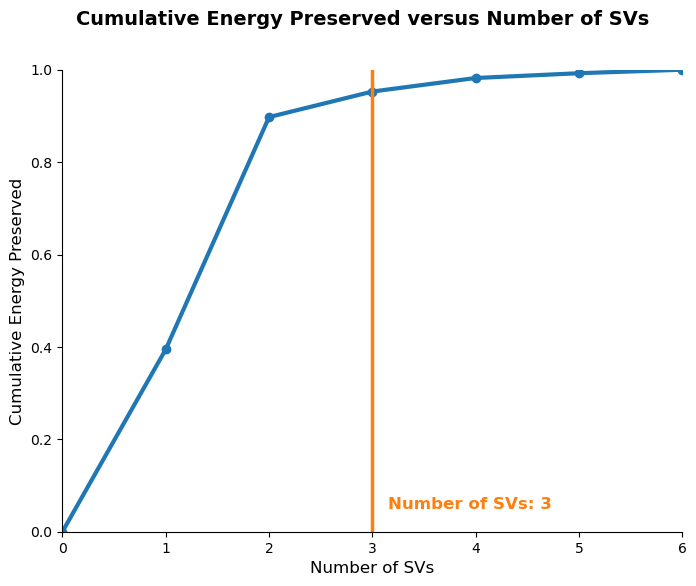

In [7]:
fig, ax, thresh = plot_energy_ratio(svd.explained_variance_ratio_);

In [8]:
X_truncated = X_transformed.iloc[:, :thresh]

## 3 Clustering Analysis

In [9]:
from utils import plot_principal_components

From our previous result, we've hypothesized that using SVD shows three noticable clusters, let's see if using $k$-Means reproduces our intuition.

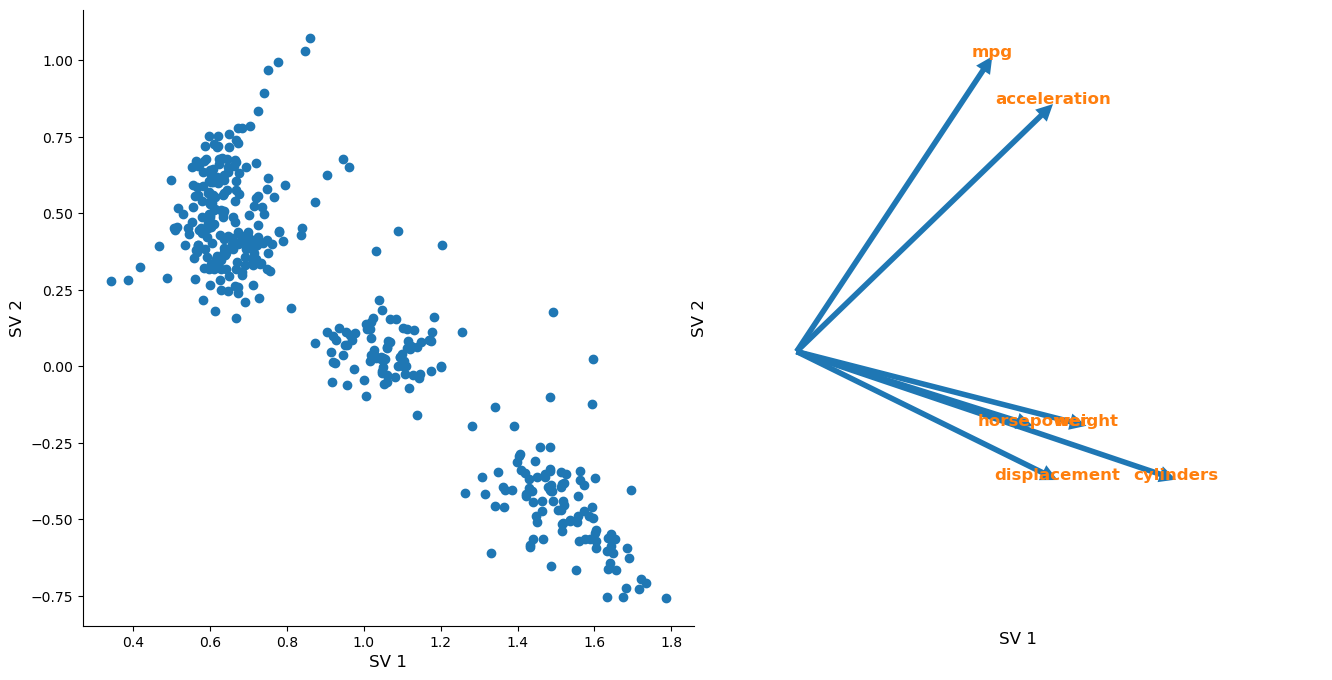

In [10]:
fig, axes = plot_principal_components(X_transformed, singular_vectors, 'SV 1', 'SV 2')
axes[1].set_ylim(singular_vectors.min().min(), singular_vectors.max().max())
axes[1].set_xlim(singular_vectors.min().min() + 0.5, singular_vectors.max().max());

In `sklearn`, the `KMeans` class performs $k$-means clustering and it follows the usual fit and predict paradigm.

In [11]:
from sklearn.cluster import KMeans

In [12]:
kmeans = KMeans(n_clusters=3, random_state=1337, n_init='auto')
kmeans.fit(X_truncated)
cluster_labels = kmeans.predict(X_truncated)

We can retrieve the cluster centers using the `cluster_centers_` attribute of the clustering object.

In [13]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_, columns=X_truncated.columns
)

In [14]:
cluster_centers

,SV 1,SV 2,SV 3
0,1.519184,-0.467886,-0.043944
1,0.646741,0.495139,-0.030875
2,1.069744,0.056942,0.094827


In [15]:
from utils import plot_clustering

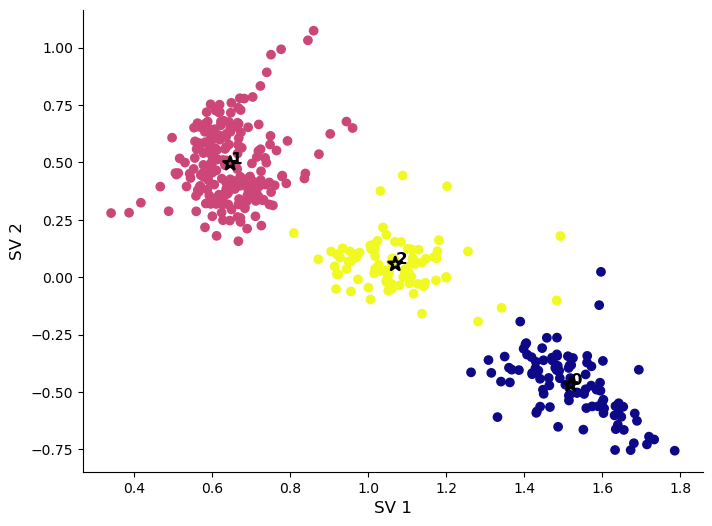

In [16]:
plot_clustering(X_truncated, 'SV 1', 'SV 2', cluster_labels, cluster_centers);

### Determining the Number of Clusters

From the previous plot, we've been able to verify our hypothesis that $k=3$ number of clusters fits well into the dataset. However, in most cases, this is usually unknown. $k$ is often dependent on the shape and scale of distribution of points and the desired clustering resolution.

There are several ways in which we can estimate the number of clusters, which we will demonstrate in the next few cells.

#### Elbow Method

The **elbow method** is based on the insight that increasing the number of clusters will reduce the **sum of within-cluster variance** or **inertia** of each cluster. Since having more clusters, allows one to capture finer group of objects that are similar to one another. However, there is a marginal effect of this reduction. As such, a heuristic for selecting the number of clusters is to use the turning point in the curve of inertia with respect to the number of clusters.

In [17]:
# Set number of trials
num_trials = 10
k_range = range(1, 21)

# Set results container - mean and std of inertias per trial
inertias_mean = []
inertias_std = []
for k in k_range:
    inertias = []
    for i in range(num_trials):
        # Fit and predict for k number of clusters setting
        cur_kmeans = KMeans(n_clusters=k, random_state=i, n_init='auto')
        cluster_labels = cur_kmeans.fit_predict(X_truncated)
        inertias.append(cur_kmeans.inertia_)
    inertias_mean.append(np.mean(inertias))
    inertias_std.append(np.std(inertias))
inertias_mean = np.array(inertias_mean)
inertias_std = np.array(inertias_std)

In [18]:
from utils import plot_internal_metric

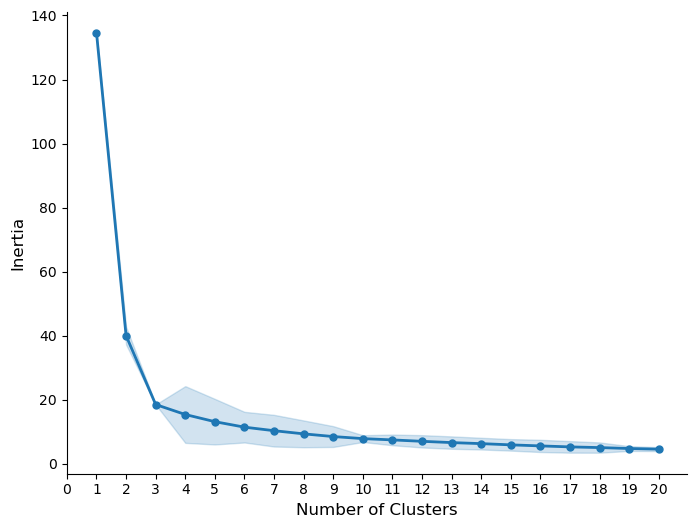

In [19]:
plot_internal_metric(k_range, inertias_mean, inertias_std, 'Inertia',
                     ebar_scale=10);

#### Calinski-Harabasz Index

Another way to estimate the number of clusters in a given data set is to look at internal validation metrics. One of which is the **Calinski-Harabasz** index, also known as the **Variance Ratio Criterion**.

Let $B(k)$ and $W(k)$ be the sum of squares of distances between and within clusters respectively,

$$
B(k) = \sum_{i=1}^k n_i || \overline{x_i} - \overline{x} ||^2_2
$$

$$
W(k) = \sum_{i=1}^k \sum_{x \in C_i} || x - \overline{x_i} ||^2_2
$$

The Calinski-Harabasz index is given by,

$$
CH(k) = \frac{\frac{B(k)}{k - 1}}{\frac{W(k)}{n - k}}
$$

In Python, the computation of Calinski-Harabasz score is implemented by `sklearn.metrics`

In [20]:
from sklearn.metrics import calinski_harabasz_score

In [21]:
# Set number of trials
num_trials = 10
k_range = range(2, 21)

# Set results container - mean and std of CH score per trial
chs_mean = []
chs_std = []
for k in k_range:
    chs = []
    for i in range(num_trials):
        # Fit and predict for k number of clusters setting
        cur_kmeans = KMeans(n_clusters=k, random_state=i, n_init='auto')
        cluster_labels = cur_kmeans.fit_predict(X_truncated)
        chs.append(calinski_harabasz_score(X_truncated, cluster_labels))
    chs_mean.append(np.mean(chs))
    chs_std.append(np.std(chs))
chs_mean = np.array(chs_mean)
chs_std = np.array(chs_std)

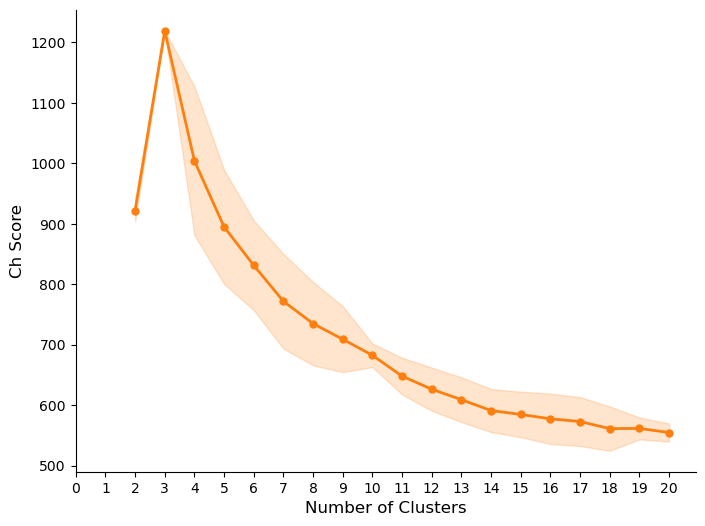

In [22]:
plot_internal_metric(k_range, chs_mean, chs_std, 'CH Score', ebar_scale=2,
                     color='tab:orange');

In this case, both the Elbow method and the CH score points to `3` as the number of clusters in the data set.

### Final Clustering

To obtain the final clustering, we perform the $k$-means algorithm multiple times with different initial cluster centers, then select the best initialization as our chosen grouping. We choose the clustering with the smallest within-cluster variation for this demonstration.

In [27]:
# Hyperparameters
num_trials = 20
k = 3

inertias = []
for i in range(num_trials):
    cur_kmeans = KMeans(n_clusters=k, random_state=i, n_init='auto')
    cluster_labels = cur_kmeans.fit_predict(X_truncated)
    inertias.append(cur_kmeans.inertia_)

# Optimal setting
kmeans = KMeans(n_clusters=k, random_state=np.argmin(inertias), n_init='auto')
cluster_labels = kmeans.fit_predict(X_truncated)
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_, columns=X_truncated.columns
)

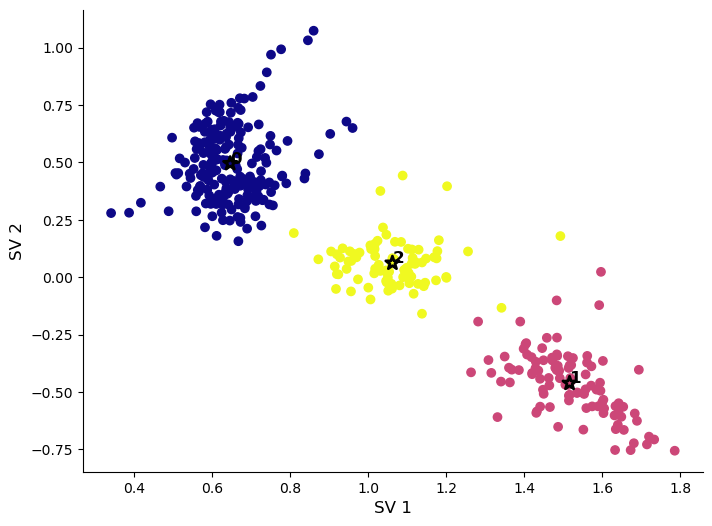

In [28]:
plot_clustering(X_truncated, 'SV 1', 'SV 2', cluster_labels, cluster_centers);

### Post-Clustering EDA

Finally, we interpret the resulting clusters by visualizing the key features of each clusters.

In [29]:
import matplotlib as mpl

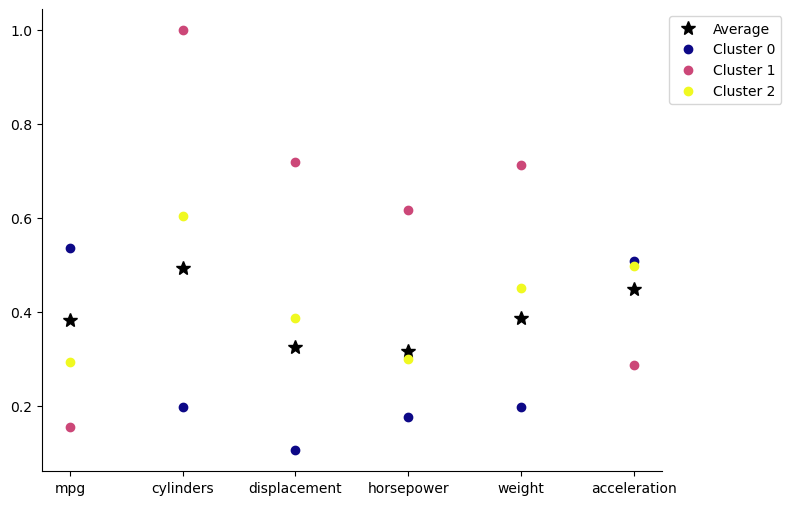

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
X.mean(axis=0).plot(style='*', ax=ax, color='black', markersize=10, label='Average')
for i in np.unique(cluster_labels):
    X.loc[cluster_labels == i].mean(axis=0).plot(
        style='o', ax=ax, color=mpl.colormaps['plasma'].resampled(3).colors[i],
        label=f'Cluster {i}'
    )

ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1., 1.,));

<img src="images/banner-down.png" style="width: 100%;">